<a href="https://colab.research.google.com/github/Sukanyareddy16-tech/github/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
data = pd.read_csv('student_data.csv')

In [ ]:
data.head()

,student_id,study_hours,attendance(%),previous_marks,internet_access,family_support,sleep_hours,final_grade,performance_label
0,1,6.6,41.5,49.3,Yes,Low,8.4,59.8,Average
1,2,1.3,65.3,32.1,Yes,Low,7.0,38.3,Poor
2,3,0.8,51.9,75.5,No,Low,6.7,49.7,Poor
3,4,7.7,49.6,59.6,No,Low,5.3,75.1,Good
4,5,7.8,46.1,56.6,No,Medium,7.6,73.7,Good


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         1000 non-null   int64  
 1   study_hours        1000 non-null   float64
 2   attendance(%)      1000 non-null   float64
 3   previous_marks     1000 non-null   float64
 4   internet_access    1000 non-null   object 
 5   family_support     1000 non-null   object 
 6   sleep_hours        1000 non-null   float64
 7   final_grade        1000 non-null   float64
 8   performance_label  1000 non-null   object 
dtypes: float64(5), int64(1), object(3)
memory usage: 70.4+ KB


In [ ]:
data.isnull().sum()

,0
student_id,0
study_hours,0
attendance(%),0
previous_marks,0
internet_access,0
family_support,0
sleep_hours,0
final_grade,0
performance_label,0


In [ ]:
data.fillna(data.mean(numeric_only=True), inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['internet_access'] = le.fit_transform(data['internet_access'])

data['family_support'] = le.fit_transform(data['family_support'])

data['performance_label'] = le.fit_transform(data['performance_label'])

In [ ]:
data.head()

,student_id,study_hours,attendance(%),previous_marks,internet_access,family_support,sleep_hours,final_grade,performance_label
0,1,6.6,41.5,49.3,1,1,8.4,59.8,0
1,2,1.3,65.3,32.1,1,1,7.0,38.3,3
2,3,0.8,51.9,75.5,0,1,6.7,49.7,3
3,4,7.7,49.6,59.6,0,1,5.3,75.1,2
4,5,7.8,46.1,56.6,0,2,7.6,73.7,2


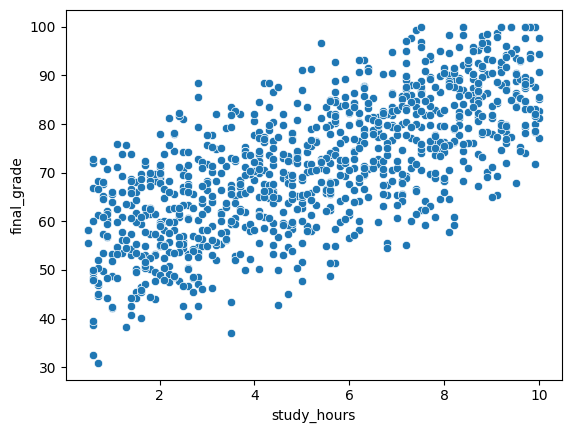

In [ ]:
sns.scatterplot(
    x='study_hours',
    y='final_grade',
    data=data
)

plt.show()

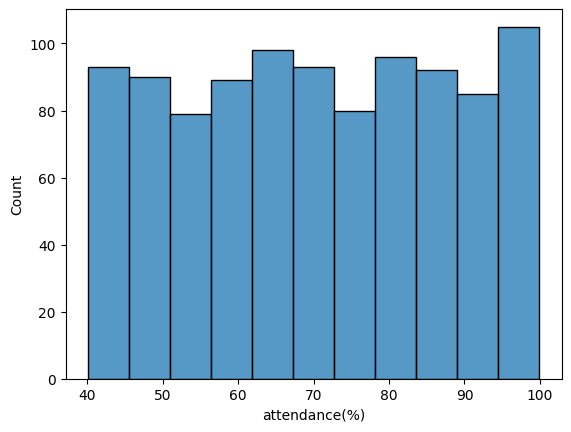

In [ ]:
sns.histplot(data['attendance(%)'])

plt.show()

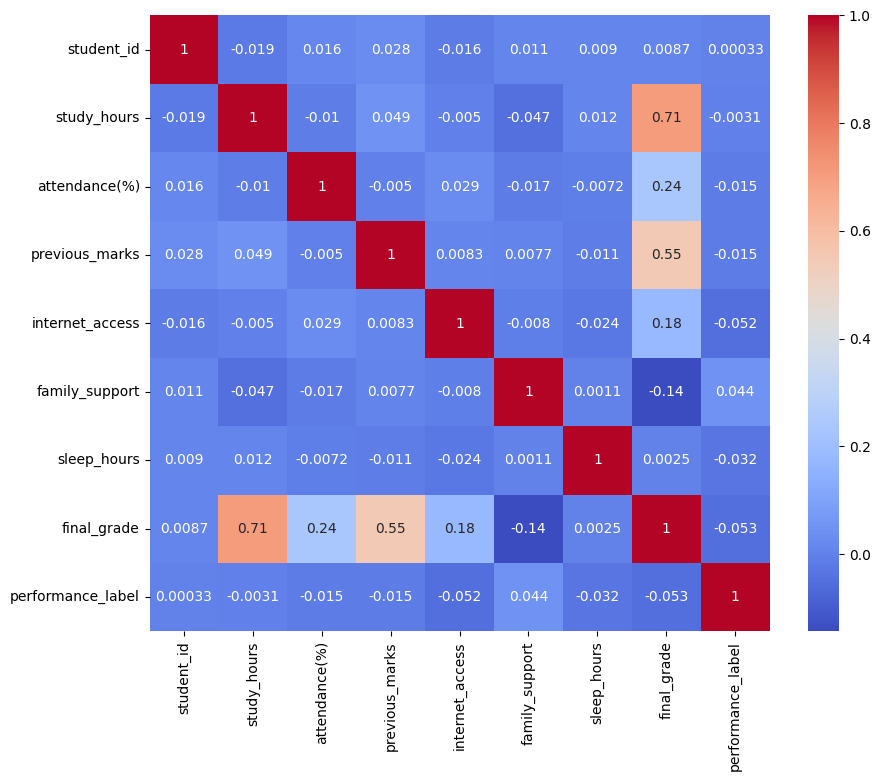

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
X = data.drop(['performance_label', 'final_grade'], axis=1)

y = data['performance_label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
pred1 = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred1)

0.47

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
pred2 = rf.predict(X_test)

In [ ]:
accuracy_score(y_test, pred2)

0.665

In [ ]:
data = data.drop('student_id', axis=1)

In [ ]:
X = data.drop(['performance_label', 'final_grade'], axis=1)

y = data['performance_label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred)

0.675

In [ ]:
data['performance_label'].value_counts()

,count
performance_label,
2,362
0,333
1,183
3,122


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
pred_dt = dt.predict(X_test)

In [ ]:
accuracy_score(y_test, pred_dt)

0.62

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
pred_lr = lr.predict(X_test)

In [ ]:
accuracy_score(y_test, pred_lr)

0.755